In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

In [ ]:
class ISICDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)

        self.img_transform = T.Compose([
            T.Resize((128,128)),
            T.ToTensor()
        ])

        self.mask_transform = T.Compose([
            T.Resize((128,128)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)


        mask_name = img_name.replace(".jpg", "_Segmentation.png")
        mask_path = os.path.join(self.mask_dir, mask_name)


        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        mask = (mask > 0).float()

        return image, mask

In [ ]:
class MobileNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(pretrained=True).features

        self.layer1 = backbone[:2]    # 64
        self.layer2 = backbone[2:4]   # 24
        self.layer3 = backbone[4:7]   # 32
        self.layer4 = backbone[7:14]  # 96
        self.layer5 = backbone[14:]   # 1280

    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)
        x5 = self.layer5(x4)

        return x1, x2, x3, x4, x5

In [ ]:
class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)


        if x.shape != skip.shape:
            x = torch.nn.functional.interpolate(x, size=skip.shape[2:])

        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [ ]:
class UNetMobileNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = MobileNetEncoder()


        self.up1 = UpBlock(1280, 96, 256)
        self.up2 = UpBlock(256, 32, 128)
        self.up3 = UpBlock(128, 24, 64)
        self.up4 = UpBlock(64, 16, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encoder(x)

        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x1)

        out = self.final(d4)


        out = torch.nn.functional.interpolate(out, size=(128,128))

        return self.sigmoid(out)

In [ ]:
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)


def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

In [ ]:
train_img_dir = "/kaggle/input/datasets/pranav6224/isic2016/isic 2016/train_data"
train_mask_dir = "/kaggle/input/datasets/pranav6224/isic2016/isic 2016/train_ground_truth"
test_img_dir = "/kaggle/input/datasets/pranav6224/isic2016/isic 2016/test_data"
test_mask_dir = "/kaggle/input/datasets/pranav6224/isic2016/isic 2016/test_ground_truth"

In [ ]:
train_dataset = ISICDataset(train_img_dir, train_mask_dir)
test_dataset = ISICDataset(test_img_dir, test_mask_dir)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:

def save_visualizations(model, loader, device, epoch, save_dir="/kaggle/working/train_outputs"):
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        preds = model(imgs)

    preds = (preds > 0.5).float()

    fig, axes = plt.subplots(5, 3, figsize=(10, 12))

    for i in range(5):
        axes[i,0].imshow(imgs[i].cpu().permute(1,2,0))
        axes[i,0].set_title("Image")

        axes[i,1].imshow(masks[i].cpu().squeeze(), cmap='gray')
        axes[i,1].set_title("GT")

        axes[i,2].imshow(preds[i].cpu().squeeze(), cmap='gray')
        axes[i,2].set_title("Pred")

        for j in range(3):
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig(f"{save_dir}/epoch_{epoch}.png")
    plt.close()

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, epochs, device, save_dir):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, masks in tqdm(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = dice_loss(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_loss += dice_loss(preds, masks).item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")
        if (epoch+1) % 2 == 0:
            save_visualizations(model, val_loader, device, epoch+1, save_dir)

    return train_losses, val_losses

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    iou_total, dice_total = 0, 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)

            iou_total += iou_score(preds, masks).item()
            dice_total += dice_score(preds, masks).item()

    return iou_total / len(loader), dice_total / len(loader)

In [ ]:
model_fe = UNetMobileNet().to(device)

# Freeze encoder
for param in model_fe.encoder.parameters():
    param.requires_grad = False

optimizer_fe = torch.optim.Adam(model_fe.parameters(), lr=1e-4)
train_losses_fe, val_losses_fe = train_model(
    model_fe,
    train_loader,
    test_loader,
    optimizer_fe,
    epochs=20,
    device=device,
    save_dir="/kaggle/working/train_outputs"
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 107MB/s] 
100%|██████████| 57/57 [00:57<00:00,  1.00s/it]


Epoch 1: Train 0.5752, Val 0.5004


100%|██████████| 57/57 [00:45<00:00,  1.26it/s]


...

100%|██████████| 57/57 [00:44<00:00,  1.27it/s]


Epoch 19: Train 0.0574, Val 0.0913


100%|██████████| 57/57 [00:44<00:00,  1.27it/s]


Epoch 20: Train 0.0561, Val 0.0935


TypeError: makedirs() got an unexpected keyword argument 'exits_ok'

In [ ]:
# Save model
os.makedirs('/kaggle/working/model_store',exist_ok=True)
torch.save(model_fe.state_dict(), "/kaggle/working/model_store/model_feature_extraction.pth")

# Evaluate
iou_fe, dice_fe = evaluate(model_fe, test_loader, device)
print("Feature Extraction IoU:", iou_fe, "Dice:", dice_fe)

Feature Extraction IoU: 0.8304453020294508 Dice: 0.9067784870664278


In [ ]:
model_ft = UNetMobileNet().to(device)

# Freeze all first
for param in model_ft.encoder.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model_ft.encoder.layer5.parameters():
    param.requires_grad = True

decoder_params = list(model_ft.up1.parameters()) + \
                 list(model_ft.up2.parameters()) + \
                 list(model_ft.up3.parameters()) + \
                 list(model_ft.up4.parameters()) + \
                 list(model_ft.final.parameters())

optimizer_ft = torch.optim.Adam([
    {'params': model_ft.encoder.layer5.parameters(), 'lr': 1e-5},  # fine-tune encoder
    {'params': decoder_params, 'lr': 1e-4}                         # train decoder
])
train_losses_ft, val_losses_ft = train_model(
    model_ft,
    train_loader,
    test_loader,
    optimizer_ft,
    epochs=20,
    device=device,
    save_dir="/kaggle/working/train_outputs_finetune"
)

# Save model
os.makedirs('/kaggle/working/model_store',exist_ok=True)
torch.save(model_fe.state_dict(), "/kaggle/working/model_store/model_finetune.pth")

# Evaluate
iou_ft, dice_ft = evaluate(model_ft, test_loader, device)
print("Fine-tuning IoU:", iou_ft, "Dice:", dice_ft)

100%|██████████| 57/57 [00:48<00:00,  1.17it/s]


Epoch 1: Train 0.5776, Val 0.4831


100%|██████████| 57/57 [00:48<00:00,  1.18it/s]


Epoch 2: Train 0.4517, Val 0.4152


100%|██████████| 57/57 [00:47<00:00,  1.19it/s]


...

Epoch 18: Train 0.0573, Val 0.0875


100%|██████████| 57/57 [00:47<00:00,  1.20it/s]


Epoch 19: Train 0.0572, Val 0.0857


100%|██████████| 57/57 [00:47<00:00,  1.19it/s]


Epoch 20: Train 0.0549, Val 0.0882
Fine-tuning IoU: 0.8390366037686666 Dice: 0.9119706004858017


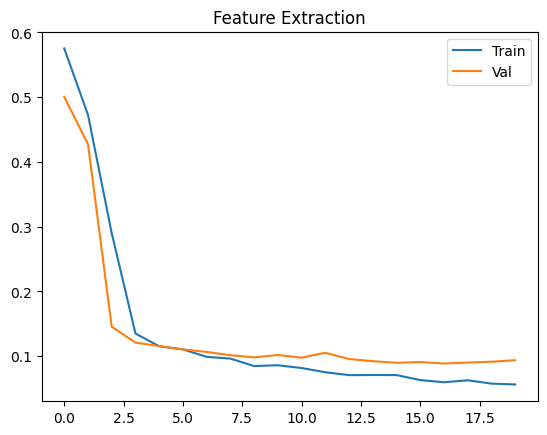

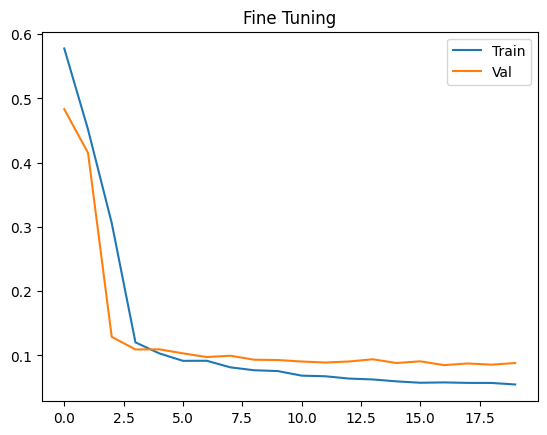

In [ ]:
def plot_losses(train, val, title):
    plt.plot(train, label="Train")
    plt.plot(val, label="Val")
    plt.legend()
    plt.title(title)
    plt.show()

plot_losses(train_losses_fe, val_losses_fe, "Feature Extraction")
plot_losses(train_losses_ft, val_losses_ft, "Fine Tuning")

In [ ]:
def save_all_grids(model, loader, device, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    idx = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader):
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            preds = (preds > 0.5).float()

            for i in range(imgs.shape[0]):
                img = imgs[i].cpu().permute(1,2,0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()

                # Create figure
                fig, axes = plt.subplots(1, 3, figsize=(9, 3))

                axes[0].imshow(img)
                axes[0].set_title("Image")

                axes[1].imshow(gt, cmap='gray')
                axes[1].set_title("Ground Truth")

                axes[2].imshow(pred, cmap='gray')
                axes[2].set_title("Prediction")

                for ax in axes:
                    ax.axis("off")

                plt.tight_layout()

                # Save
                plt.savefig(os.path.join(save_dir, f"grid_{idx}.png"), dpi=200)
                plt.close()

                idx += 1

In [ ]:
save_all_grids(
    model_fe,
    test_loader,
    device,
    save_dir="/kaggle/working/feature_predictions"
)

100%|██████████| 24/24 [02:08<00:00,  5.33s/it]


In [ ]:
save_all_grids(
    model_ft,
    test_loader,
    device,
    save_dir="/kaggle/working/finetune_predictions"
)

100%|██████████| 24/24 [02:09<00:00,  5.41s/it]


In [ ]:
import shutil

# zip entire working directory (models + outputs + predictions)
shutil.make_archive(
    '/kaggle/working/isic_results',
    'zip',
    '/kaggle/working'
)

print("ZIP created at /kaggle/working/isic_results.zip")

ZIP created at /kaggle/working/isic_results.zip
